In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Car_Price_Prediction.csv")
df

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657
...,...,...,...,...,...,...,...,...
995,Toyota,Model D,2002,1.9,5445,Petrol,Manual,22765.597091
996,Honda,Model B,2020,3.1,149112,Diesel,Manual,30392.575567
997,Ford,Model C,2008,1.9,195387,Petrol,Automatic,16446.892292
998,Toyota,Model A,2003,4.4,246,Petrol,Automatic,27396.156708


In [3]:
df.describe()

,Year,Engine Size,Mileage,Price
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,2010.688000,2.798300,97192.48700,25136.615530
std,6.288577,1.024137,59447.31576,5181.401368
min,2000.000000,1.000000,56.00000,6704.953524
25%,2005.000000,1.900000,44768.75000,21587.878370
50%,2011.000000,2.800000,94411.50000,25189.325247
75%,2016.000000,3.700000,148977.75000,28806.368974
max,2021.000000,4.500000,199867.00000,41780.504635


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          1000 non-null   str    
 1   Model         1000 non-null   str    
 2   Year          1000 non-null   int64  
 3   Engine Size   1000 non-null   float64
 4   Mileage       1000 non-null   int64  
 5   Fuel Type     1000 non-null   str    
 6   Transmission  1000 non-null   str    
 7   Price         1000 non-null   float64
dtypes: float64(2), int64(2), str(4)
memory usage: 62.6 KB


In [5]:
df.isnull().sum()

Make            0
Model           0
Year            0
Engine Size     0
Mileage         0
Fuel Type       0
Transmission    0
Price           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

Make                str
Model               str
Year              int64
Engine Size     float64
Mileage           int64
Fuel Type           str
Transmission        str
Price           float64
dtype: object

In [7]:
df.describe(include="all")

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
count,1000,1000,1000.000000,1000.000000,1000.00000,1000,1000,1000.000000
unique,5,5,NaN,NaN,NaN,3,2,NaN
top,Ford,Model B,NaN,NaN,NaN,Diesel,Manual,NaN
freq,225,212,NaN,NaN,NaN,344,511,NaN
mean,NaN,NaN,2010.688000,2.798300,97192.48700,NaN,NaN,25136.615530
std,NaN,NaN,6.288577,1.024137,59447.31576,NaN,NaN,5181.401368
min,NaN,NaN,2000.000000,1.000000,56.00000,NaN,NaN,6704.953524
25%,NaN,NaN,2005.000000,1.900000,44768.75000,NaN,NaN,21587.878370
50%,NaN,NaN,2011.000000,2.800000,94411.50000,NaN,NaN,25189.325247
75%,NaN,NaN,2016.000000,3.700000,148977.75000,NaN,NaN,28806.368974


<Axes: >

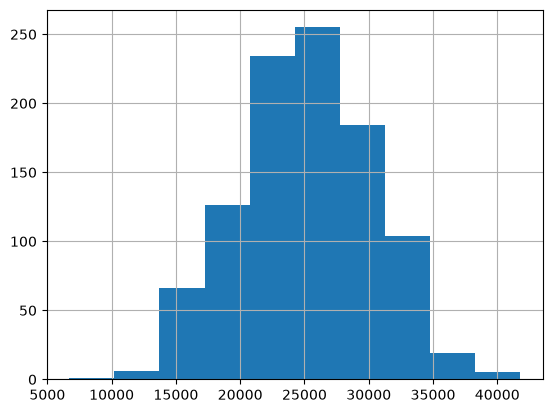

In [9]:
df["Price"].hist()

<Axes: >

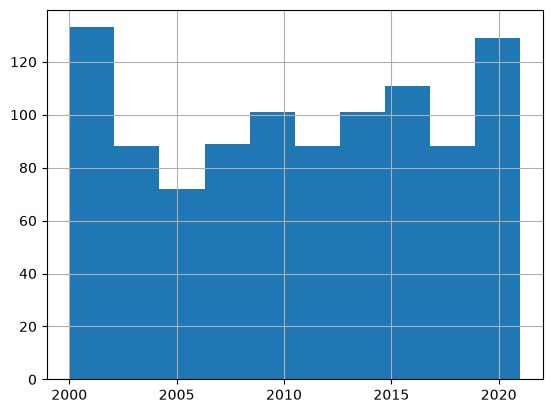

In [10]:
df["Year"].hist()

<Axes: >

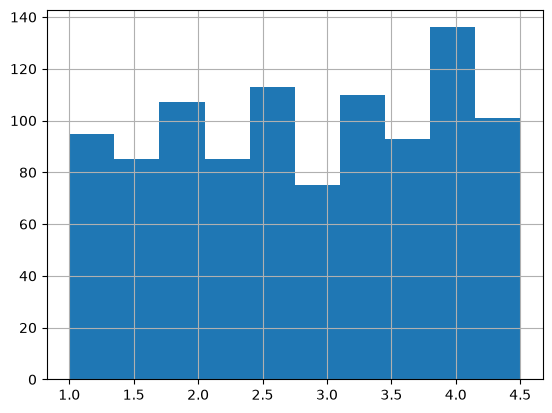

In [11]:
df["Engine Size"].hist()

<Axes: >

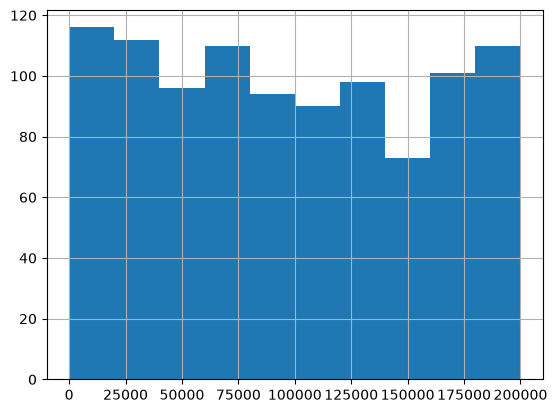

In [12]:
df["Mileage"].hist()

In [13]:
df.select_dtypes(include="number").corr()

,Year,Engine Size,Mileage,Price
Year,1.000000,-0.012190,0.016376,0.609631
Engine Size,-0.012190,1.000000,-0.014815,0.383951
Mileage,0.016376,-0.014815,1.000000,-0.556560
Price,0.609631,0.383951,-0.556560,1.000000


In [14]:
for col in ["Make", "Model", "Fuel Type", "Transmission"]:
    print(col, ":", df[col].unique())

Make : <StringArray>
['Honda', 'Ford', 'BMW', 'Audi', 'Toyota']
Length: 5, dtype: str
Model : <StringArray>
['Model B', 'Model C', 'Model A', 'Model D', 'Model E']
Length: 5, dtype: str
Fuel Type : <StringArray>
['Petrol', 'Electric', 'Diesel']
Length: 3, dtype: str
Transmission : <StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str


In [15]:
df.nunique()

Make               5
Model              5
Year              22
Engine Size       36
Mileage          997
Fuel Type          3
Transmission       2
Price           1000
dtype: int64

In [16]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 7)
(200, 7)
(800,)
(200,)


In [20]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [21]:
numeric_features = ["Year", "Engine Size", "Mileage"]
categorical_features = ["Make", "Model", "Fuel Type", "Transmission"]